In [1]:
import os
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [5]:
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)

# Load dataset
df = pd.read_csv(csv_path)

print("\nFirst 5 Records")
df.head()


First 5 Records


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

print("\nCleaned Reviews")
print(df[["review", "clean_review"]].head())


Cleaned Reviews
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


In [9]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nAccuracy")
print(accuracy_score(y_test, y_pred))


Accuracy
0.8554


In [11]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4961
    positive       0.85      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [12]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[4206  755]
 [ 691 4348]]


In [13]:
print("\nSentiment Counts")
print(df["sentiment"].value_counts())


Sentiment Counts
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


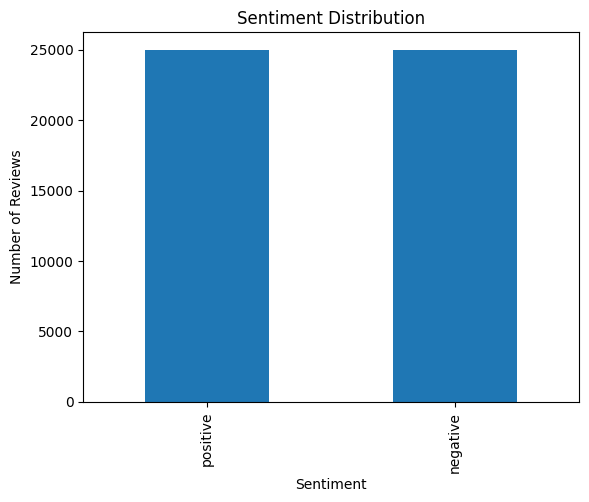

In [14]:
df["sentiment"].value_counts().plot(kind="bar",title="Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

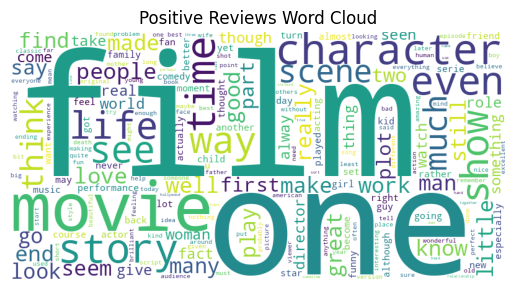

In [15]:
positive_text = " ".join(df[df["sentiment"] == "positive"]["clean_review"])
wordcloud = WordCloud(width=800,height=400,background_color="white").generate(positive_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

In [17]:
review = input("\nEnter a movie review:\n")
review = clean_text(review)
review_vector = vectorizer.transform([review])
prediction = model.predict(review_vector)
print("\nPredicted Sentiment:", prediction[0])


Enter a movie review:
Lion King

Predicted Sentiment: positive
